In [ ]:
import numpy as np
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt

from tqdm import tqdm

from loka.data import load_breakthrough_states
from loka.models import BreakthroughCNN

import os
import pandas as pd

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

In [ ]:
filename = "/home/axelbjarkar/RU/T-404-LOKA-code/data/e.txt"
X,Y = load_breakthrough_states(filename, two_channel=True)

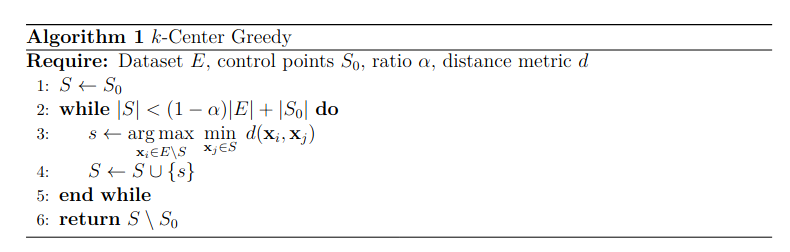

\begin{equation}
    ||\mathbf{a} - \mathbf{b}||^2 = ||\mathbf{a}||^2 + ||\mathbf{b}||^2 - 2\mathbf{a}^T \mathbf{b}
\end{equation}

In [ ]:
def k_center_order(X, max_ratio, device, S0=None):
    n = X.shape[0]
    k = int(max_ratio * n)  # |S \ S0|
    phi = torch.as_tensor(X.reshape(n, -1), dtype=torch.float32, device=device)  # flattened; float to avoid uint8 overflow
    sq = phi.pow(2).sum(-1)  # ||x||^2, precomputed once

    def sq_dist_to(C):  # squared distance from every point to its nearest row of C -> [n]
        d = sq[:, None] + C.pow(2).sum(-1) - 2 * phi @ C.T
        return d.clamp_min(0).min(dim=1).values

    if isinstance(S0, str) and S0 == 'rand':
        C0 = torch.rand(100, phi.shape[1], device=device)  # 100 random vectors, uniform in [0, 1)
        min_dist = sq_dist_to(C0)
    elif S0 is not None:
        C0 = torch.as_tensor(S0.reshape(S0.shape[0], -1), dtype=torch.float32, device=device)
        min_dist = sq_dist_to(C0)
    else:
        min_dist = torch.full((n,), torch.inf, device=device)

    selected = torch.zeros(n, dtype=torch.bool, device=device)
    order = torch.empty(k, dtype=torch.long, device=device)
    for t in tqdm(range(k), desc='k-center'):
        scores = min_dist.masked_fill(selected, -torch.inf)  # remove those that have been selected
        i = torch.argmax(scores)
        selected[i] = True
        order[t] = i
        min_dist = torch.minimum(min_dist, sq_dist_to(phi[i:i+1]))  # only the new center can shrink distances
    return order.cpu().numpy()

In [ ]:
order = k_center_order(X, 1, device, S0='rand')

In [ ]:
start = 0.01
end = 0.9
steps = 50
batch_size = 512

splits = np.linspace(start, end, num=steps, endpoint=True)
mse_values = []
prc_values = []

X_t = torch.FloatTensor(X).to(device)
Y_t = torch.FloatTensor(Y).to(device)

epochs = 50
pbar = tqdm(total=steps * epochs, desc='training')

for seed, ratio in enumerate(splits):
    # Get the first datapoints from the herded dataset
    train_idx = order[:int(ratio * len(X))]
    X_train, Y_train = X[train_idx], Y[train_idx] 

    torch.manual_seed(SEED)  # same init weights each time
    model = BreakthroughCNN().to(device)

    # training setup
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()
    
    # convert data to tensors
    X_train_t = torch.FloatTensor(X_train).to(device)
    Y_train_t = torch.FloatTensor(Y_train).to(device)
    
    # training loop
    for epoch in range(epochs):
        perm = torch.randperm(len(X_train_t), device=device)  # new shuffle each epoch
        
        for i in range(0, len(X_train_t), batch_size):
            idx = perm[i:i + batch_size]
            xb, yb = X_train_t[idx], Y_train_t[idx]
    
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
        pbar.update(1)

    pbar.set_postfix(model=f'{seed+1}/{steps}', ratio=f'{ratio:.2f}', loss=f'{loss.item():.4f}')
    
    # evaluate
    with torch.no_grad():
        test_preds = model(X_t)
        mse = loss_fn(test_preds, Y_t).item()
        mse_values.append(mse)
        prc_values.append(ratio)

pbar.close()

In [ ]:
data_dir = "/home/axelbjarkar/RU/T-404-LOKA-code/data/results"
os.makedirs(data_dir, exist_ok=True)  # create the folder if it doesn't exist yet

csv_file = f'{data_dir}/k_center_rand_control_points_subset_50epochs.csv'

# one row per split: training ratio and MSE
pd.DataFrame({'ratio': prc_values, 'mse': mse_values}).to_csv(csv_file, index=False)